# CHO cell bioreactor: mAb production

This notebook simulates a constant-temperature batch using the balances from
Kumar et al. (2022), [*Multi-objective optimization of monoclonal antibody
production in bioreactor*](https://doi.org/10.1016/j.cep.2021.108720).
Reference links are listed in [references](../docs/references.md).

The default run lasts **5,000 minutes at 308 K with no inlet or outlet flow**.
It uses reactor run 1's initial conditions but does not reproduce the paper's
full feeding/temperature schedule. The results are simulated, not experimental.
See [model review](../docs/model_review.md) for corrections and limitations.

This is the simulation stage of the LSTM project described in [project_proposal.pdf](../docs/project_proposal.pdf).
The training and forecasting stage is implemented in `baselines/univariate_lstm.py`; see
[report_alignment.md](../docs/report_alignment.md) for the complete research workflow.

In [1]:
%matplotlib inline
from pathlib import Path
import os
import sys

PROJECT_ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents)
                     if (p / "bioreactor.py").is_file() and (p / "forecasting").is_dir()), None)
if PROJECT_ROOT is None:
    raise RuntimeError("Open this notebook from within the project directory.")
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
Path("results/simulation").mkdir(parents=True, exist_ok=True)
Path("data").mkdir(parents=True, exist_ok=True)

from dataclasses import asdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display

from bioreactor import (
    DEFAULT_DURATION, DEFAULT_INITIAL_STATE, Operation, Parameters,
    export_csv, observations, simulate,
)

## Equations and units

The integrated state is $[V, X_v, P, S, L, X_d]$. Volume is in mL;
cell densities are in $10^6$ cells/mL; mAb ($P$) is in mg/L; glucose ($S$)
and lactate ($L$) are in g/L. Time is in minutes and temperature in kelvin.

$$\mu=\mu_{max}\frac{S}{K_sX_v+S}\frac{K_L}{K_L+L}
(1-K_PP)\exp(-K_1/T),\qquad k_d=\mu_d\exp(-K_2/T).$$

The signed glucose rate and the corrected lactate rate (equations 11–12) are

$$q_S=-\mu/Y_{X/S}-m_S,$$
$$q_L=(\mu/Y_{X/L}+Y_{L/S}q_S)(1-L/L_{max,1})
+m_L(1-L/L_{max,2}).$$

The lactate multiplier applies to both terms in the first parentheses.
`lacmax1=628.0` follows the printed Table 3; the original notebook used
6283.06289. The original fitting data/code are unavailable, so this discrepancy
remains a provenance limitation. The other parameters retain the notebook's
extra digits.

Viability is derived as $100X_v/(X_v+X_d)$, with 0% used as a reporting
convention for an empty culture. Integrating $X_d$ avoids division by viability.
The complete flow balances are implemented once in `bioreactor.py`.

In [2]:
# Edit these conditions to explore another constant operating point.
parameters = Parameters()
operation = Operation(
    inlet_flow=0.0,       # mL/min
    sample_flow=0.0,      # well-mixed outlet, mL/min
    perfusion_flow=0.0,   # cells AND mAb retained, mL/min
    feed_glucose=18.0,    # g/L (numerically equal to mg/mL)
    temperature=308.0,    # K
)

# [V, viable cells, mAb, glucose, lactate, DEAD cells]
initial_state = np.array(DEFAULT_INITIAL_STATE)
start_time = 0.0
total_time = DEFAULT_DURATION
no_of_data_points = int(total_time) + 1
tspan = np.linspace(start_time, start_time + total_time, no_of_data_points)

parameter_rows = [f"| {name} | {value:.10g} |" for name, value in asdict(parameters).items()]
display(Markdown("| Parameter | Value |\n| --- | --- |\n" + "\n".join(parameter_rows)))

| Parameter | Value |
| --- | --- |
| mumax | 0.153065905 |
| ks | 0.850356543 |
| mud | 3.95525447e-05 |
| ypx | 6.61966255e-05 |
| mp | 0.012086688 |
| yxs | 2.05140571 |
| ms | 0.000110167094 |
| kl | 344.210432 |
| yxl | 1.98322526 |
| yls | 0.0933512253 |
| kp | 0.000687871174 |
| lacmax1 | 628 |
| lacmax2 | 0.499990345 |
| mlac | 1.88752322e-05 |
| k1 | 1688.90312 |
| k2 | 524.079503 |

## Integrate and inspect

The solver validates inputs and monitors glucose depletion, lactate depletion,
and the linear mAb inhibition limit. If a boundary is crossed, the run raises
a descriptive error rather than presenting a failed trajectory as usable data.
The default batch reaches glucose depletion at approximately 7,480 minutes;
longer runs require revised conditions or an independently justified model
for starvation.

`states` contains dead cells in column 5. `y` uses the original notebook's
reporting order, with **viability (%)** in column 5.

In [3]:
states = simulate(tspan, initial_state, parameters, operation)
y = observations(states)

labels = [
    "Volume (mL)", "Viable cells (10^6 cells/mL)", "mAb (mg/L)",
    "Glucose (g/L)", "Lactate (g/L)", "Viability (%)",
]
rows = [f"| {label} | {first:.6g} | {last:.6g} |"
        for label, first, last in zip(labels, y[0], y[-1])]
display(Markdown("| Quantity | Initial | Final |\n| --- | ---: | ---: |\n" + "\n".join(rows)))
print(f"Simulated {len(tspan):,} samples over {total_time:g} minutes.")
print(f"Final mAb mass in reactor: {states[-1, 2] * states[-1, 0] / 1000:.3f} mg")

| Quantity | Initial | Final |
| --- | ---: | ---: |
| Volume (mL) | 5650 | 5650 |
| Viable cells (10^6 cells/mL) | 0.7 | 5.28163 |
| mAb (mg/L) | 0 | 161.624 |
| Glucose (g/L) | 6.05 | 2.2964 |
| Lactate (g/L) | 0.12 | 1.76985 |
| Viability (%) | 99 | 98.0773 |

Simulated 5,001 samples over 5000 minutes.
Final mAb mass in reactor: 913.176 mg


## State trajectories

Each panel has its own units. The plots cover the same time interval and
samples as the exported CSV. The volume is constant in the default batch.

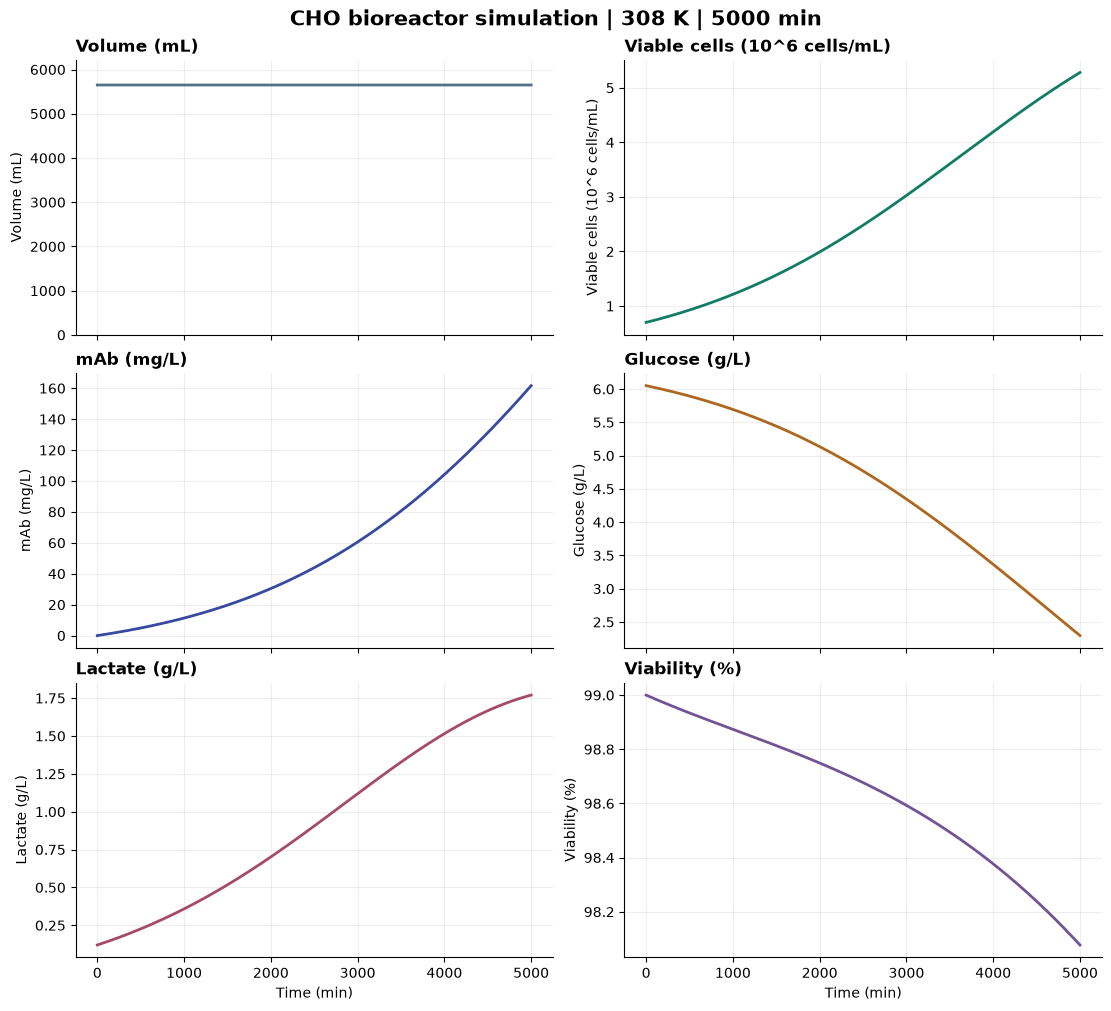

In [4]:
with plt.rc_context({"font.size": 10, "axes.spines.top": False, "axes.spines.right": False}):
    fig, axes = plt.subplots(3, 2, figsize=(11, 10), sharex=True, layout="constrained")
    colors = ["#527384", "#137C66", "#374AA0", "#AE6721", "#A64B67", "#725495"]
    for index, (ax, label, color) in enumerate(zip(axes.flat, labels, colors)):
        ax.plot(tspan, y[:, index], color=color, linewidth=2)
        ax.set_title(label, loc="left", fontweight="bold")
        ax.set_ylabel(label)
        ax.grid(alpha=0.2)
        ax.ticklabel_format(axis="y", style="plain", useOffset=False)
    for ax in axes[-1]:
        ax.set_xlabel("Time (min)")
    axes[0, 0].set_ylim(0, max(y[:, 0]) * 1.1)
    fig.suptitle(f"CHO bioreactor simulation | {operation.temperature:g} K | {total_time:g} min",
                 fontsize=15, fontweight="bold")
    fig.savefig("results/simulation/overview.png", dpi=180)
    fig.savefig("results/simulation/overview.pdf")
    plt.show()

## Export and interpretation

The CSV preserves the original seven-column format: time, volume, viable
cells, mAb, glucose, lactate, and viability. It is regenerated from the same
trajectory used above. The CSV is the canonical tabular export.

These plots verify numerical behavior only. The supplied files do not include
independent experimental measurements, the original parameter fit, or the training code used for the old slides. Correcting a transcription does not establish
experimental accuracy.

In [5]:
export_csv("data/example_batch.csv", tspan, states)
for filename in ("data/example_batch.csv", "results/simulation/overview.png", "results/simulation/overview.pdf"):
    print(f"Saved {Path(filename).resolve().name}")

Saved example_batch.csv
Saved overview.png
Saved overview.pdf


## Continue to the completed forecasting project

Open [the forecasting notebook](02_mab_forecasting.ipynb) for the final comparison of improved LSTM, MLP,
regression, and baseline models on 88 separate simulated batches. The selected
ridge model forecasts up to 1,000 minutes from multivariate observed history.

```sh
python predict_mab.py        # Use the trained model
python run_project.py        # Reproduce the full study and report
```

The first univariate LSTM in `baselines/univariate_lstm.py` is retained as a historical baseline.
Read [final_report.pdf](../docs/final_report.pdf) for current results, calibration, and noise sensitivity.
